## __Binary images and connected components__
por Jesús David Petro Ramos - T00065696

<div
  style="border-left: 4px solid rgb(23, 146, 153); background-color: rgba(23, 146, 153, 0.1); padding: 0.5em; border-radius: 6px;"
>
  <strong style="color: rgb(23, 146, 153);">
    <svg
      xmlns="http://www.w3.org/2000/svg"
      width="15"
      height="15"
      viewBox="0 0 24 24"
      fill="none"
      stroke="currentColor"
      stroke-width="2"
      stroke-linecap="round"
      stroke-linejoin="round"
      style="vertical-align: -1px; margin-right: 4px;"
    >
      <circle cx="12" cy="12" r="10" />
      <path d="M12 16v-4" />
      <path d="M12 8h.01" /></svg
    >TODO </strong
  ><br />
  <span style="color: #000;">process the image blobs.jpg and count the number of white blobs</span>
</div>

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import io

# Configuration parameters
AREA_MIN = 500
AREA_MAX = 100_000
CONN = 4      # Connectivity: 4-way or 8-way


In [2]:
def plot_grayscale(image: np.ndarray, ax: plt.Axes = None, **kwargs) -> None:
    """
    Plot a grayscale image using Matplotlib.

    Parameters
    ----------
    image : np.ndarray
        Grayscale image to display.
    ax : matplotlib.axes.Axes, optional
        Axis object to draw the image on. If None, a new figure and axis are created.
    **kwargs
        Additional keyword arguments passed to `ax.set()`.

    Returns
    -------
    None
    """
    if ax is None:
        _, ax = plt.subplots()

    ax.imshow(image, cmap="gray")
    ax.set(**kwargs)
    ax.axis("off")


In [3]:
def filter_stats(stats: np.ndarray) -> bool:
    """
    Determine whether a connected component (blob) is valid based on its statistics.

    Parameters
    ----------
    stats : np.ndarray
        A 1D array containing the statistics of a connected component, 
        as returned by `cv2.connectedComponentsWithStats`.

    Returns
    -------
    bool
        True if the blob meets the validity criteria, False otherwise.
    """
    area = stats[cv2.CC_STAT_AREA]

    # Validate area range
    is_valid_area = AREA_MIN < area < AREA_MAX

    # Additional filters can be added here if needed
    return is_valid_area


Image information:
Shape: (512, 512)
Data type: uint8
Unique values: [  0   1 254 255]


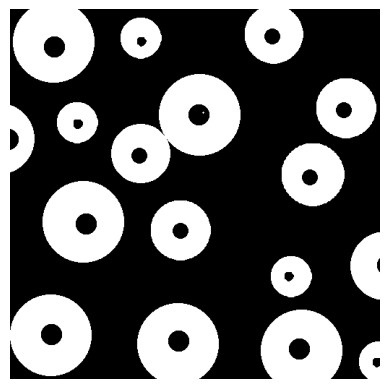

In [4]:
# Load and display a grayscale image
IMAGE_URL = "https://github.com/agmarrugo/computer-vision-utb/blob/main/data/blobs.jpg?raw=true"

image = io.imread(IMAGE_URL)
plot_grayscale(image)

print("Image information:")
print(f"Shape: {image.shape}")
print(f"Data type: {image.dtype}")
print(f"Unique values: {np.unique(image)}")


### __Sin separar los blobs de la mitad__

Número de blobs esperados: 16, considerando que los dos blobs parcialmente conectados en la parte central de la imagen se cuentan como uno solo.

In [16]:
# Compute connected components and their statistics
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    image, connectivity=CONN, ltype=cv2.CV_32S
)

# Show basic info
print(f"Labels (including background): {num_labels}")
print(f"Labels shape: {labels.shape}")
print(f"Stats shape: {stats.shape}")
print(f"Centroids shape: {centroids.shape}")


Labels (including background): 582
Labels shape: (512, 512)
Stats shape: (582, 5)
Centroids shape: (582, 2)


In [17]:
# Filter components based on area criteria
stats_filtered = np.array([
    s for s in stats if filter_stats(s)
])

print(f"Filtered stats shape: {stats_filtered.shape}")


Filtered stats shape: (16, 5)


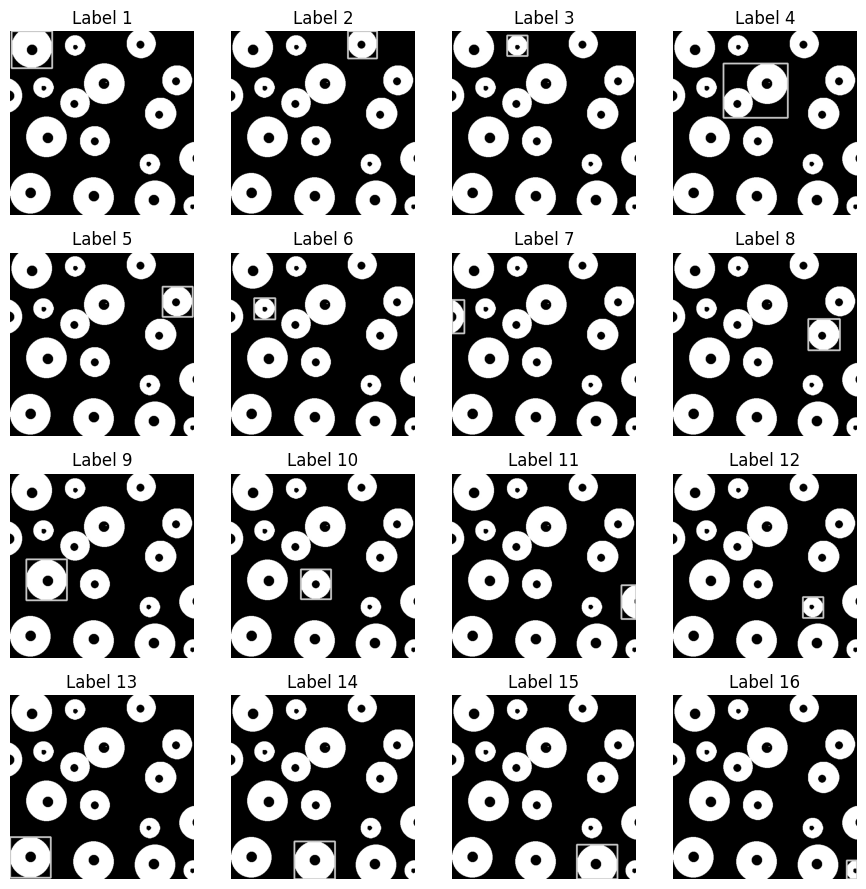

In [18]:
# Create a 4x4 grid for visualization
fig, axes = plt.subplots(4, 4, figsize=(9, 9))
num_labels = stats_filtered.shape[0]

# Plot each filtered component with its bounding box
for i, ax in zip(range(num_labels), axes.flatten()):
    x = stats_filtered[i, cv2.CC_STAT_LEFT]
    y = stats_filtered[i, cv2.CC_STAT_TOP]
    w = stats_filtered[i, cv2.CC_STAT_WIDTH]
    h = stats_filtered[i, cv2.CC_STAT_HEIGHT]

    output_img = image.copy()
    cv2.rectangle(output_img, (x, y), (x + w, y + h), 200, 3)

    plot_grayscale(output_img, ax=ax, title=f"Label {i + 1}")

# Adjust layout
fig.tight_layout()
plt.show()


### __Separando los blobs de la mitad__
Número de blobs esperados: 17, considerando por separado los blobs que están parcialmente unidos en la parte central de la imagen.



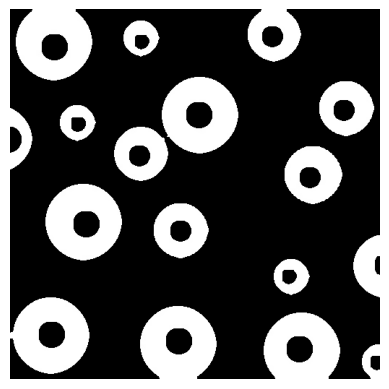

In [19]:
# Valid kernel shapes: MORPH_RECT, MORPH_CROSS, MORPH_ELLIPSE
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (8, 8))

# Apply erosion once to separate slightly connected blobs
eroded_image = cv2.erode(image, kernel, iterations=1)

# Display the eroded result
plot_grayscale(eroded_image)


In [20]:
# Compute connected components on the eroded image
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    eroded_image,
    connectivity=CONN,
    ltype=cv2.CV_32S
)


Filtered stats count: 17
Filtered stats shape: (17, 5)


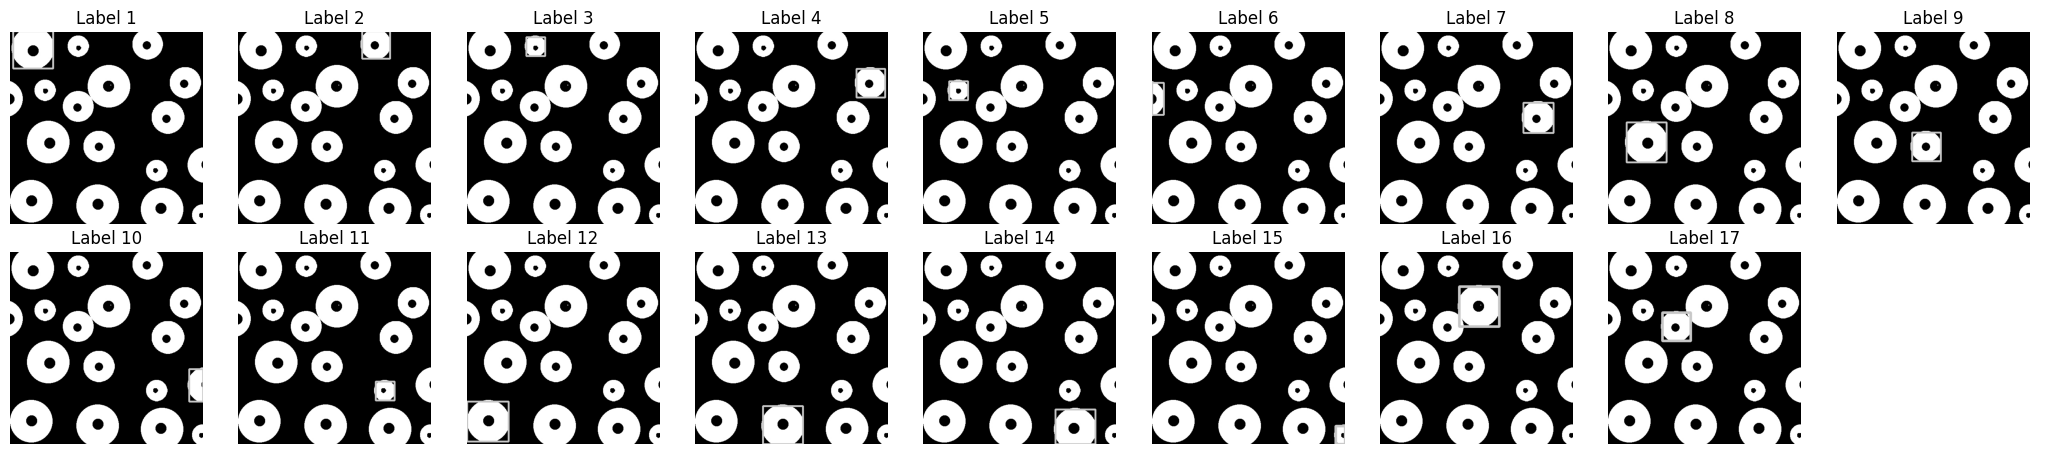

In [21]:
# Filter and arrange stats (exclude background row if present at index 0)
stats_filtered = [s for s in stats[1:]] if stats.shape[0] > 0 else []
stats_filtered = [s for s in stats_filtered if filter_stats(s)]
num_labels = len(stats_filtered)
print(f"Filtered stats count: {num_labels}")

# Move indices 3 and 7 to the end (if they exist) to show them last
to_move_idxs = [3, 7]
to_move = []
for idx in sorted(to_move_idxs):
    if 0 <= idx < len(stats_filtered):
        to_move.append(stats_filtered[idx])

for idx in sorted(to_move_idxs, reverse=True):
    if 0 <= idx < len(stats_filtered):
        del stats_filtered[idx]

stats_filtered.extend(to_move)

# Convert to NumPy array for convenience
stats_filtered = np.array(stats_filtered)
print(f"Filtered stats shape: {stats_filtered.shape}")

# Grid: 2 rows × 9 columns (fits up to 18 components, good for 17)
rows, cols = 2, 9
fig, axes = plt.subplots(rows, cols, figsize=(2.3 * cols, 2.3 * rows))
axes = axes.flatten()

limit = min(num_labels, rows * cols)
last_k_to_highlight = 3  # highlight the last three plotted
start_highlight = max(0, limit - last_k_to_highlight)

# Draw bounding boxes
for i in range(limit):
    x = int(stats_filtered[i, cv2.CC_STAT_LEFT])
    y = int(stats_filtered[i, cv2.CC_STAT_TOP])
    w = int(stats_filtered[i, cv2.CC_STAT_WIDTH])
    h = int(stats_filtered[i, cv2.CC_STAT_HEIGHT])

    # Thicker box for the last three components (simple visual emphasis)
    thickness = 5 if i >= start_highlight else 3

    out_img = image.copy()
    cv2.rectangle(out_img, (x, y), (x + w, y + h), 200, thickness)
    plot_grayscale(out_img, ax=axes[i], title=f"Label {i + 1}")

# Hide any unused axes
for ax in axes[limit:]:
    ax.axis("off")

fig.tight_layout()
plt.show()
